In [1]:
import json
import multiprocessing as mp
import pickle

import numpy as np
import torch
from matplotlib import pyplot as plt

from src.models import BinaryClassifier
from src.utils import get_filepath
from src.priors import build_priors, integrate_nd_vegas
from src.data import draw_data, get_data
from src.training import train, test_model
from src.plotting import (
    _enforce_markers,
    plot_all_rocs,
    plot_error_and_hpd_width,
    plot_errorbars,
    plot_log_ratio_error_vs_distance,
    plot_log_ratio_exact_vs_predicted,
    plot_prior_contours,
    plot_prior_sample_histograms,
    plot_ratio_violins,
    plot_reweighting_summary,
    plot_reweighted_distributions,
    plot_reweighting_swd_vs_distance,
    plot_training_tests,
)
from src.posterior import (
    create_inference_data,
    get_first_column_scatter_data,
    get_posteriors_and_errors,
)
from src.verification import (
    build_quantitative_verification_bundle,
    calculate_all_ratios,
    evaluate_nd_reweighting_quality,
    evaluate_pairwise_log_ratio_quality,
    reweight_distributions,
)

plt.rc("axes", prop_cycle=plt.cycler(color=plt.get_cmap("Set1").colors))

In [2]:
config = {
    "data": {
        "prior_args": {
            "uniform": None,
            "normal": (5, 4),
            "exponential": (0.1,),
            "grid": (0.2,),
        },
        "parameter_range": (0, 10),
        "std_dev": 2,
        "n_parameters": 2,
        "n_train": 70_000,
        "n_test": 15_000,
        "n_validation": 15_000,
    },
    "classifier": {
        "n_inputs": 2, #has to be equal to n_parameters
        "n_hidden_layers": 3,
        "n_units": 64,
    },
    "training": {
        "learning_rate": 0.001,
        "batch_size": 128,
        "n_epochs": 5,
        "model_iterations": 1,
    },
}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = np.random.default_rng(0)

In [3]:
priors, prior_samplers, param_min, param_max = build_priors(config, generator)

#### Prior Distirbutions:

(<Figure size 1000x800 with 6 Axes>,
 array([<Axes: title={'center': 'uniform'}, xlabel='$\\theta_0$', ylabel='$\\theta_1$'>,
        <Axes: title={'center': 'normal'}, xlabel='$\\theta_0$', ylabel='$\\theta_1$'>,
        <Axes: title={'center': 'exponential'}, xlabel='$\\theta_0$', ylabel='$\\theta_1$'>,
        <Axes: >], dtype=object))

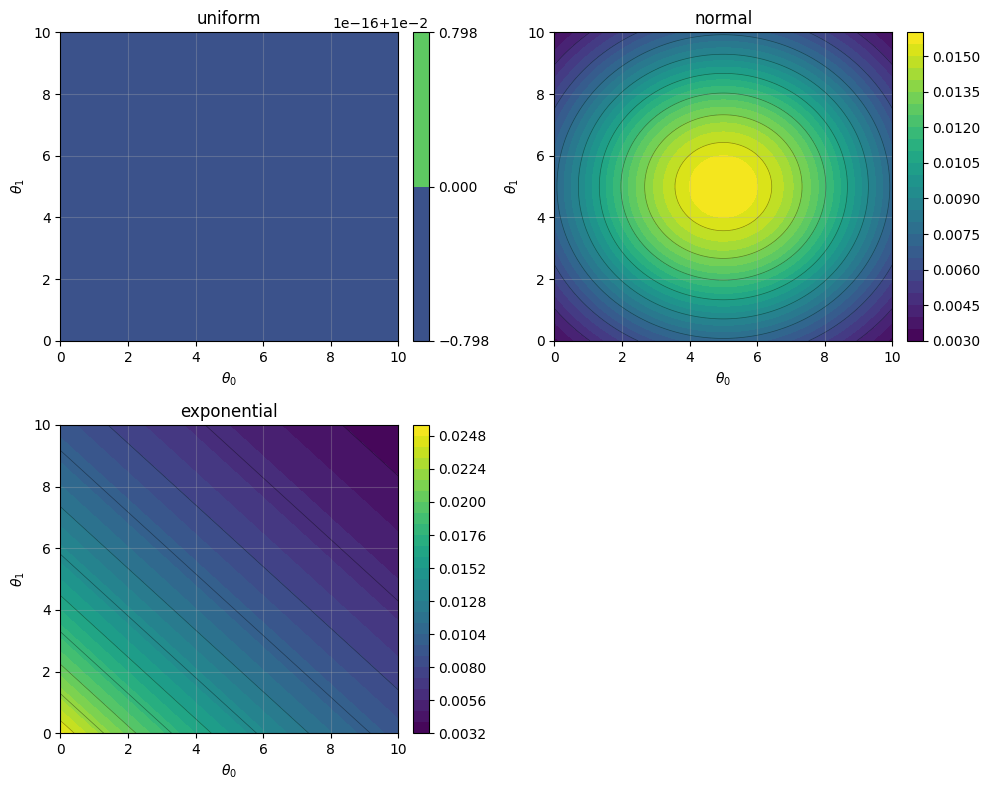

In [4]:
plot_prior_contours(
    priors,
    parameter_range=config["data"]["parameter_range"],
    n_parameters=config["data"]["n_parameters"],
)

(<Figure size 1000x800 with 3 Axes>,
 array([<Axes: title={'center': 'Samples from uniform prior'}, xlabel='$\\theta_0$', ylabel='$\\theta_1$'>,
        <Axes: title={'center': 'Samples from normal prior'}, xlabel='$\\theta_0$', ylabel='$\\theta_1$'>,
        <Axes: title={'center': 'Samples from exponential prior'}, xlabel='$\\theta_0$', ylabel='$\\theta_1$'>,
        <Axes: >], dtype=object))

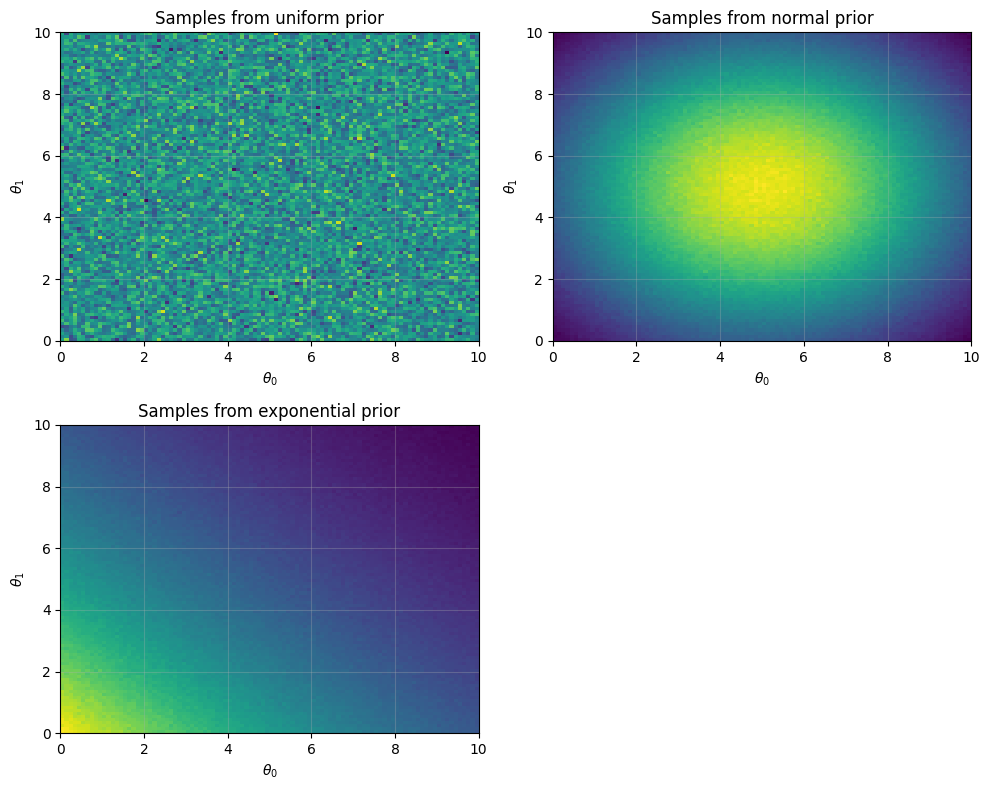

In [5]:
plot_prior_sample_histograms(prior_samplers, config)

In [6]:
for prior in priors:
    integral = integrate_nd_vegas(
        prior,
        [(param_min, param_max)] * config["data"]["n_parameters"],
        nitn=20,
        neval=10_000,
    )[0]
    print(f"Integral of {prior.__name__}: {integral:.5f}")

Integral of uniform: 1.00000
Integral of normal: 1.00000
Integral of exponential: 1.00000


#### Data:

In [7]:
example_train_set, example_validation_set, example_test_set = get_data(
    prior_samplers[0],
    config,
    generator,
    show_output=True,
)

Train: torch.Size([70000, 2]), torch.Size([70000]), torch.Size([70000, 2])
Test: torch.Size([15000, 2]), torch.Size([15000]), torch.Size([15000, 2])
Validation: torch.Size([15000, 2]), torch.Size([15000]), torch.Size([15000, 2])


#### Run:

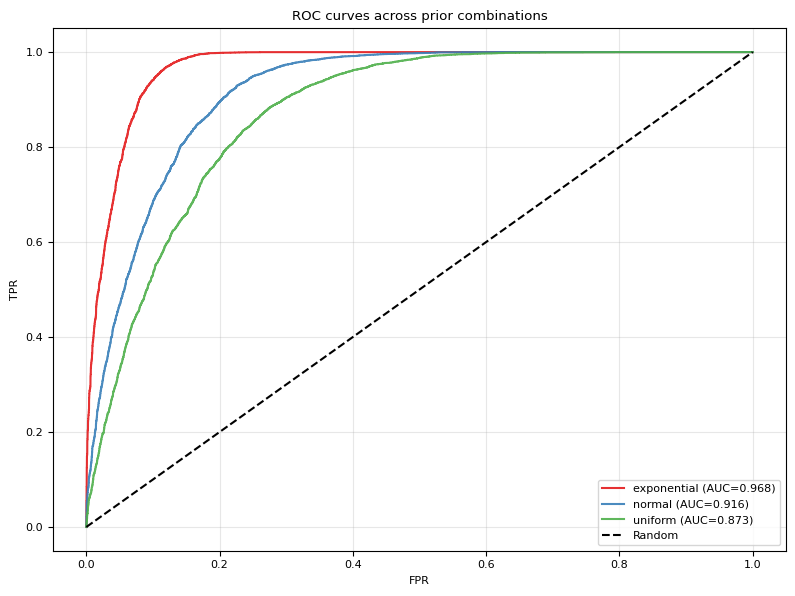

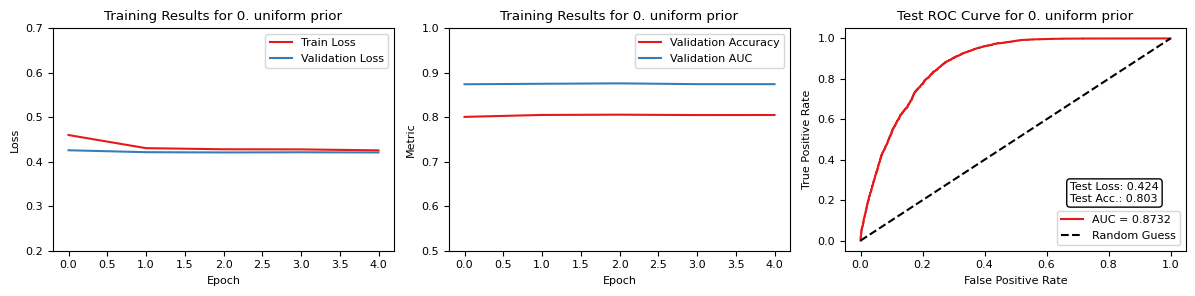

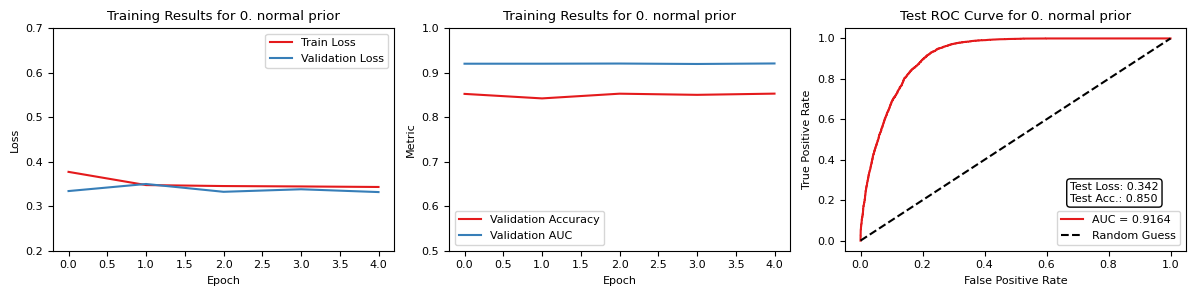

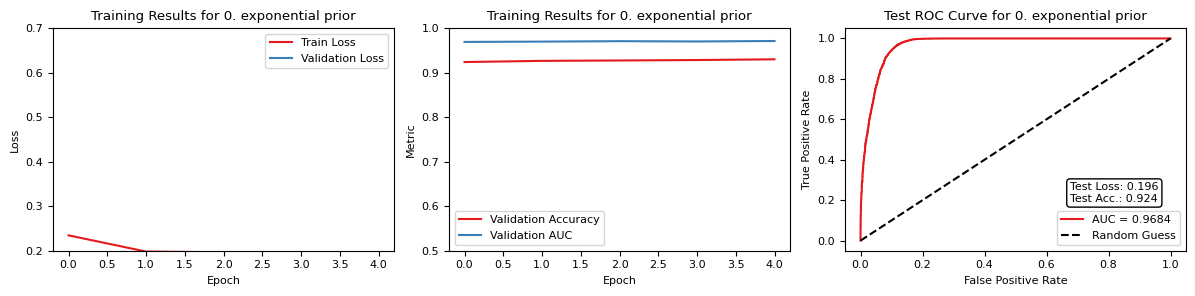

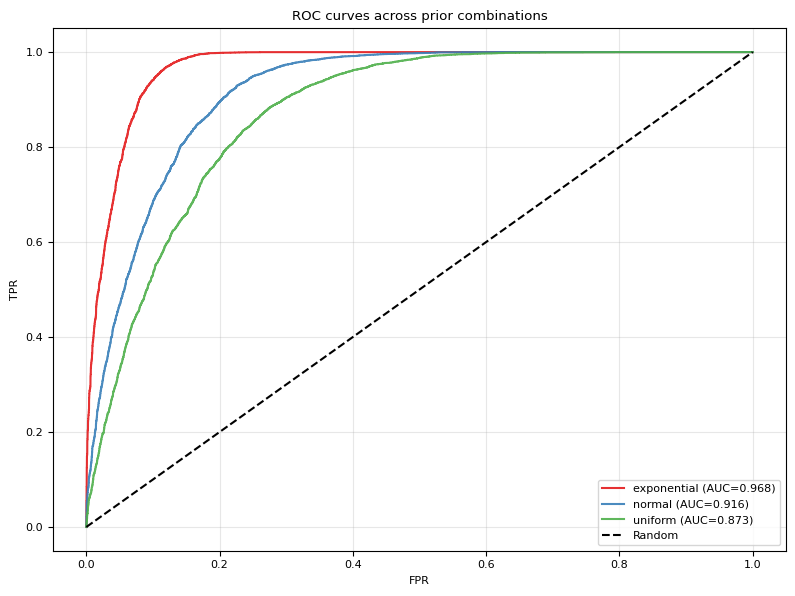

In [8]:
models = [{} for _ in range(config["training"]["model_iterations"])]
test_results = [{} for _ in range(config["training"]["model_iterations"])]

for prior_sampler in prior_samplers:
    prior_name = prior_sampler.__name__
    for i in range(config["training"]["model_iterations"]):
        train_set, validation_set, test_set = get_data(
            prior_sampler,
            config,
            generator,
            show_output=False,
        )
        model = BinaryClassifier(config)
        model, training_results = train(
            model,
            *train_set,
            *validation_set,
            config=config,
            device=device,
            show_output=False,
        )
        filename_plots = get_filepath(f"training/training_{i}/training_{prior_name}_prior.svg", config)
        filename_model = get_filepath(f"models/models_{i}/model_{prior_name}_prior.pth", config)
        torch.save(model.state_dict(), filename_model)
        test_result = test_model(model, *test_set, device=device, show_output=False)
        plot_training_tests(training_results, test_result, f"{i}. {prior_name}", filename_plots)
        models[i][prior_name] = model
        test_results[i][prior_name] = test_result

plot_all_rocs(test_results, filename=get_filepath("training/all_roc_curves.svg", config))

#### Posterior:

In [9]:
save = True
n_repititions_per_parameter = 20
n_parameters = int(2e2)

posterior_qmc_samples = 2**16
posterior_eval_batch_size = 2**15
posterior_max_model_evals_per_prior = int(2e15)
posterior_qmc_seed = 2026

parameters_min_max = config["data"]["parameter_range"]
all_parameters_in_range = [
    np.linspace(parameters_min_max[0], parameters_min_max[1], n_parameters)
    for _ in range(config["data"]["n_parameters"])
]
print(f"GPU: {device.type}; CPUs: {mp.cpu_count()}")

filename_errorbars = get_filepath("posterior_errors/errorbars.svg", config) if save else None
filename_errorbars_ratios = get_filepath("posterior_errors/errorbars_ratios.svg", config) if save else None
filename_error_and_hpd_width = get_filepath("posterior_errors/error_and_hpd_width.svg", config) if save else None
filename_error_and_hpd_width_ratios = get_filepath("posterior_errors/error_and_hpd_width_ratios.svg", config) if save else None
filename_posteriors_data = get_filepath("posterior_errors/results_data.pkl", config) if save else None

GPU: cuda; CPUs: 72


In [10]:
inference_data = create_inference_data(
    parameters_min_max,
    config,
    generator,
    n_parameters_to_infer_per_dim=50,
    margin=0,
    n_repititions_per_parameter=n_repititions_per_parameter,
)
all_posteriors, all_ratios, all_HPDs_posterior, all_HPDs_ratio = get_posteriors_and_errors(
    inference_data,
    all_parameters_in_range,
    models=models,
    priors=priors,
    device=device,
    n_qmc_samples=posterior_qmc_samples,
    eval_batch_size=posterior_eval_batch_size,
    max_model_evals_per_prior=posterior_max_model_evals_per_prior,
    qmc_seed=posterior_qmc_seed,
)

if save:
    with open(filename_posteriors_data, "wb") as handle:
        pickle.dump(
            {
                "all_HPDs_posterior": all_HPDs_posterior,
                "all_HPDs_ratio": all_HPDs_ratio,
                "inference_data": inference_data,
                "all_posteriors": all_posteriors,
                "all_ratios": all_ratios,
                "all_parameters_in_range": all_parameters_in_range,
                "n_repititions_per_parameter": n_repititions_per_parameter,
                "n_parameters": n_parameters,
            },
            handle,
        )

[posterior] eval_batch_size=32768, combo_batch_size=1, obs_chunk_size=20, theta_chunk_size=1638, forward_pairs=32760, qmc_samples=65536


Calculating posteriors and errors (QMC samples)...:   0%|                                                                        | 0/150000 [00:00<?, ?it/s]

Calculating posteriors and errors (QMC samples)...: 100%|██████████████████████████████████████████████████████████| 150000/150000 [05:58<00:00, 418.63it/s]


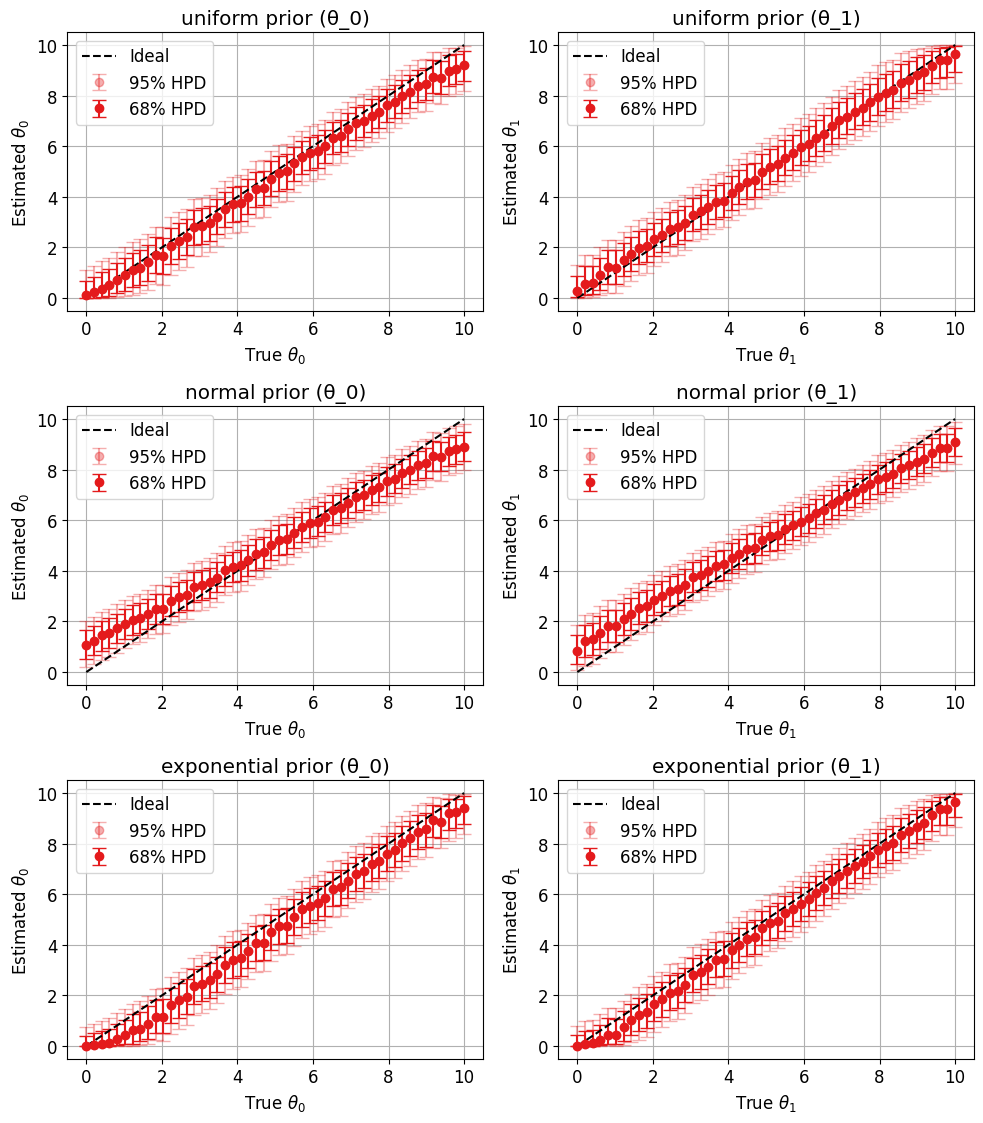

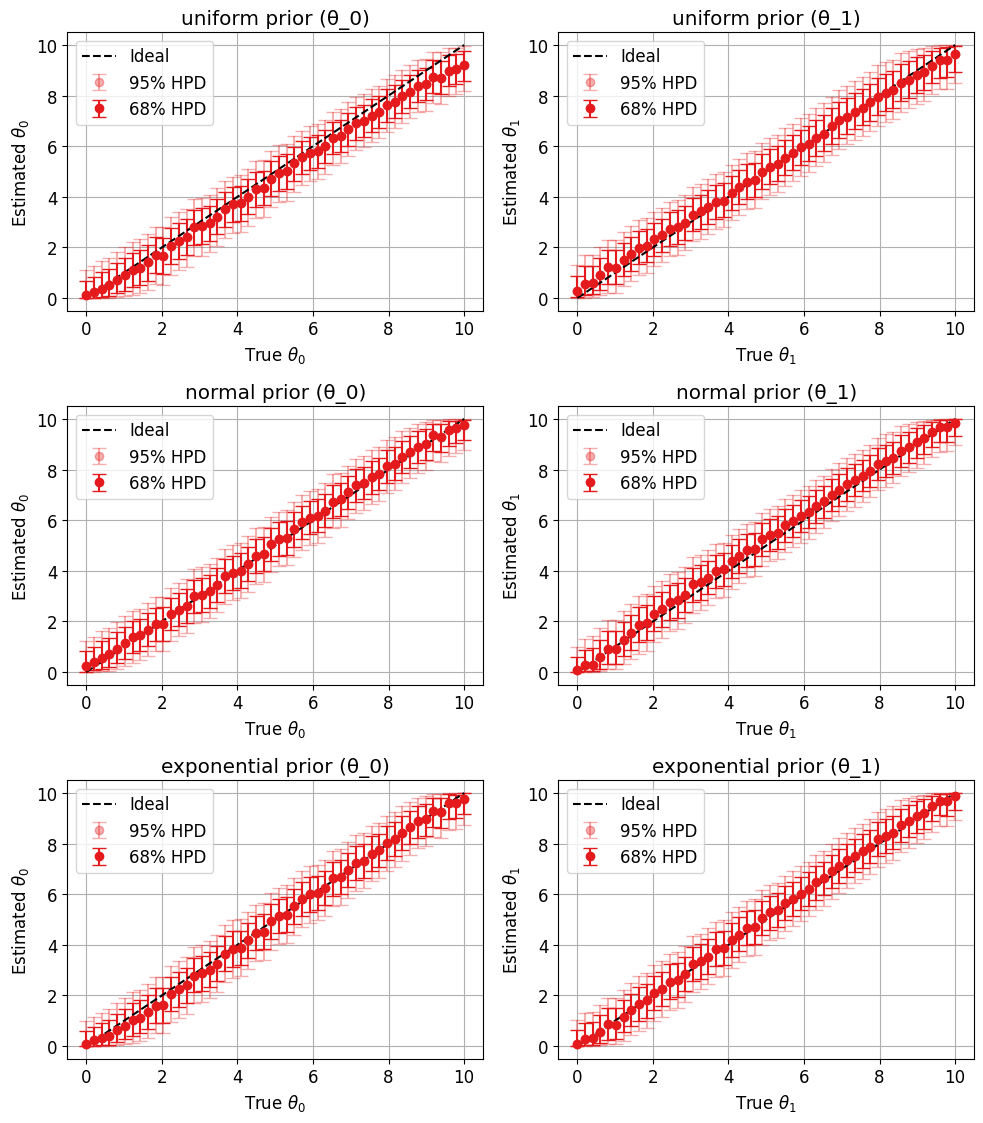

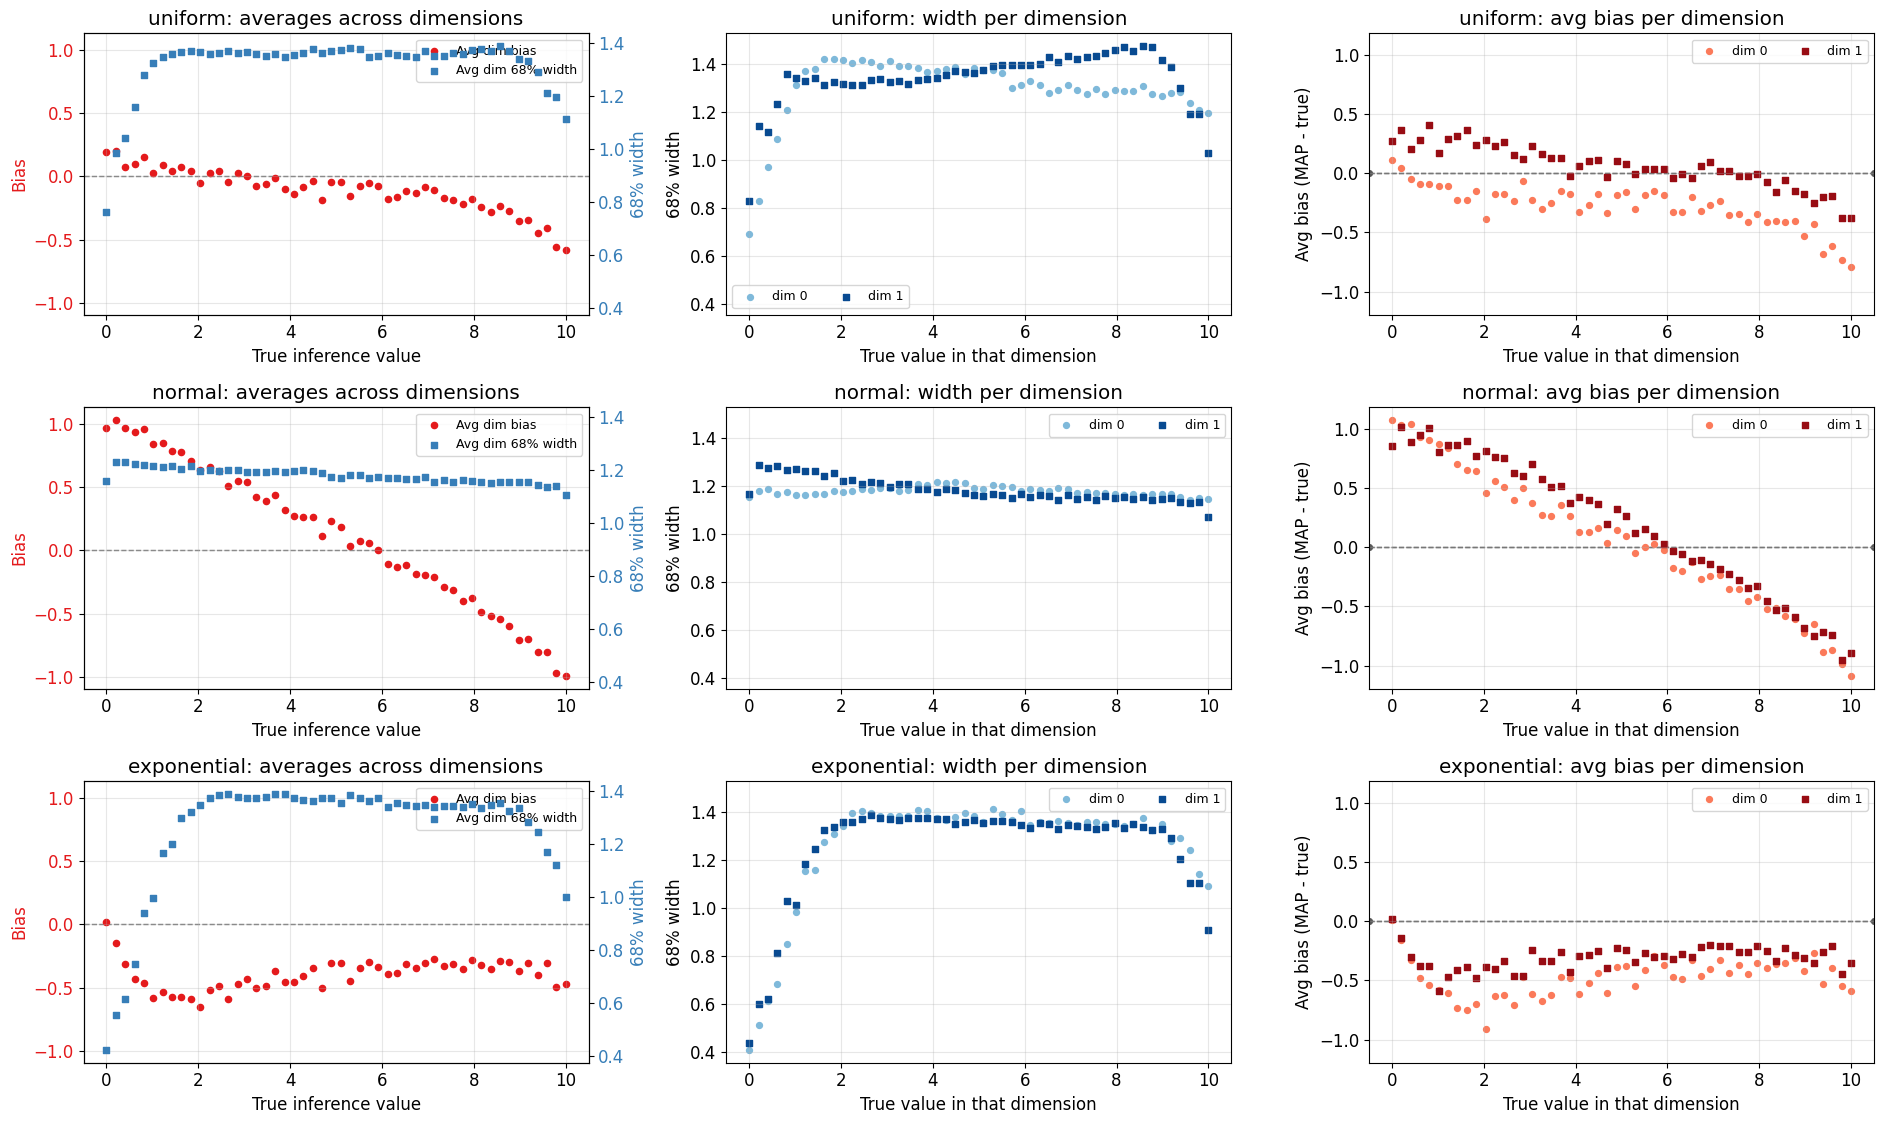

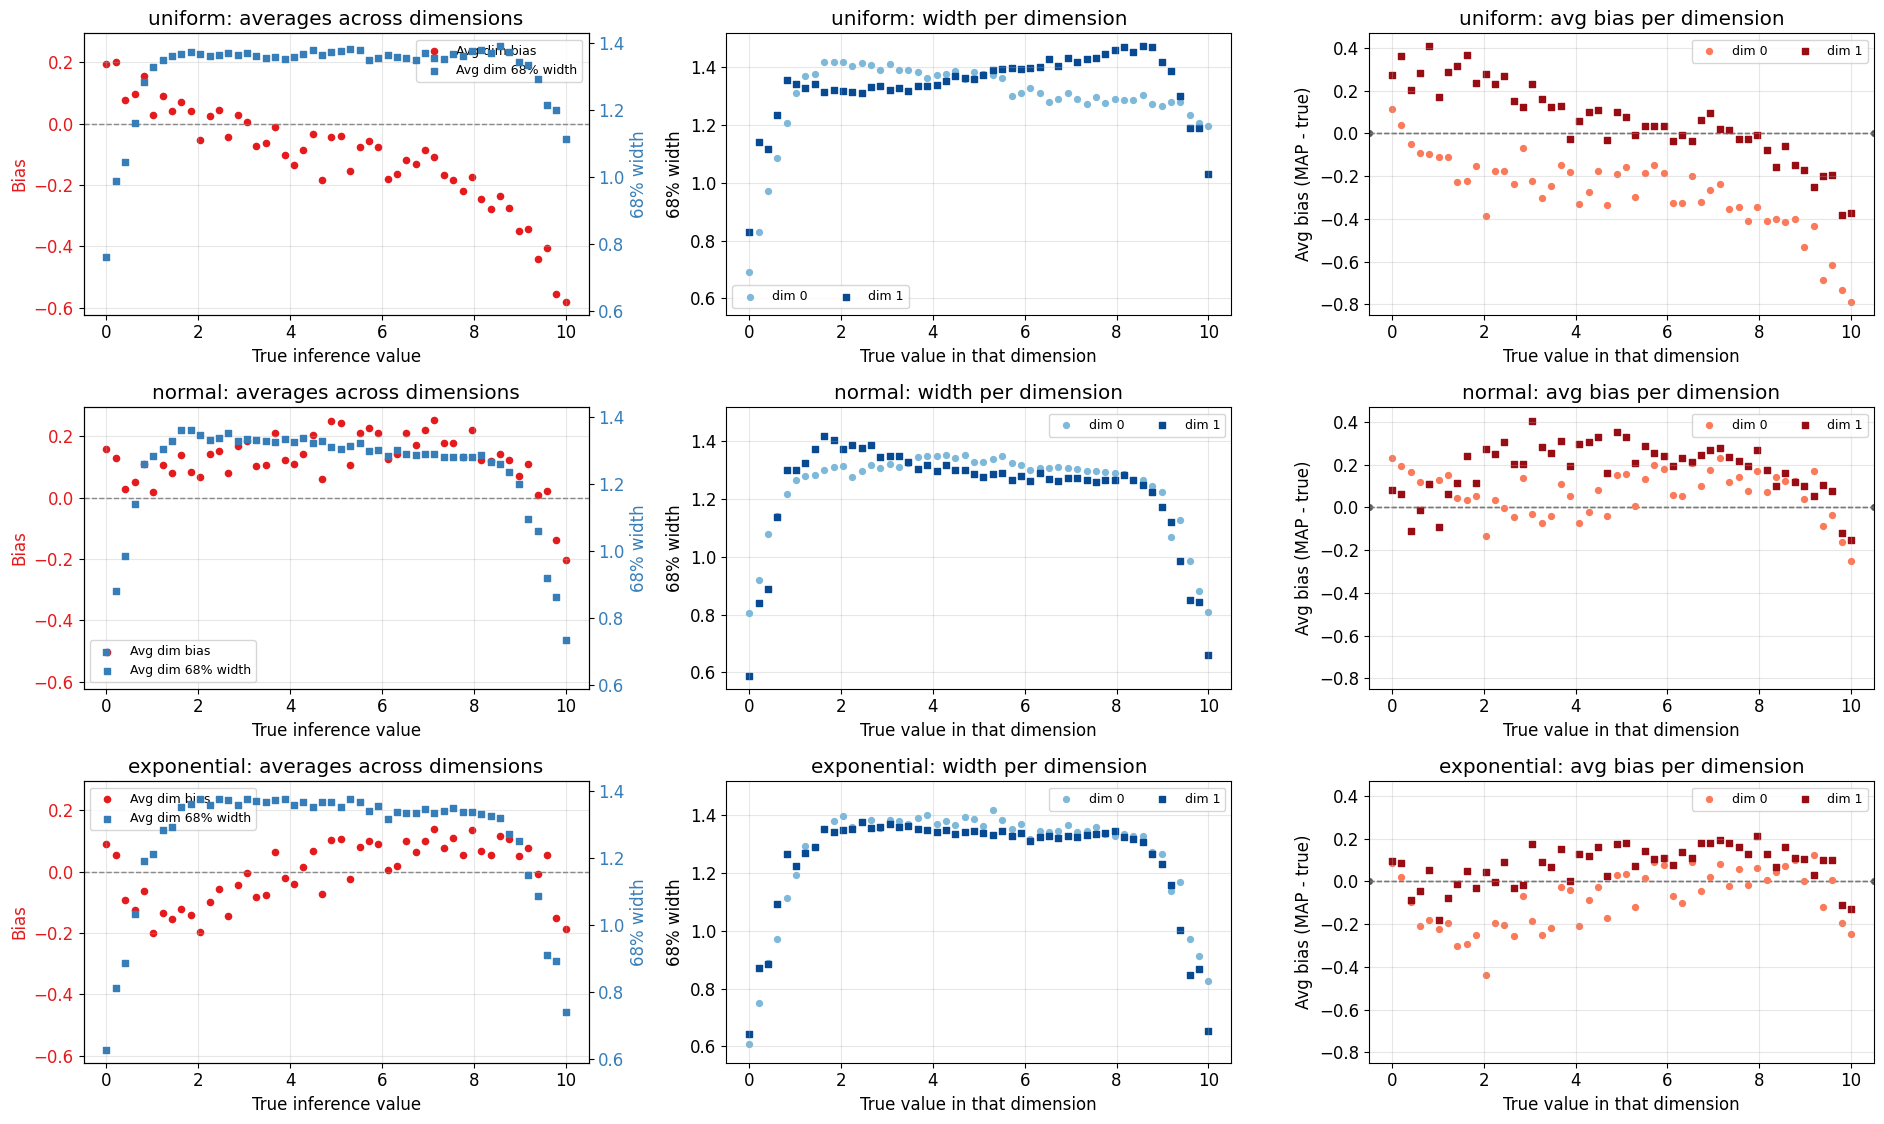

In [11]:
plot_errorbars(
    all_HPDs_posterior,
    inference_data,
    all_posteriors,
    all_parameters_in_range,
    show_annotations=False,
    filename=filename_errorbars,
)
plot_errorbars(
    all_HPDs_ratio,
    inference_data,
    all_ratios,
    all_parameters_in_range,
    show_annotations=False,
    filename=filename_errorbars_ratios,
)

fig, _ = plot_error_and_hpd_width(
    all_HPDs_posterior,
    inference_data,
    all_posteriors,
    all_parameters_in_range,
    filename=filename_error_and_hpd_width,
)
_enforce_markers(fig, filename=filename_error_and_hpd_width)

fig, _ = plot_error_and_hpd_width(
    all_HPDs_ratio,
    inference_data,
    all_ratios,
    all_parameters_in_range,
    filename=filename_error_and_hpd_width_ratios,
)
_enforce_markers(fig, filename=filename_error_and_hpd_width_ratios);

In [12]:
averaged_bias_error = get_first_column_scatter_data(
    inference_data,
    all_ratios,
    all_parameters_in_range,
    all_HPDs_ratio,
)
averaged_bias_error

{'uniform': {'x': array([ 0.        ,  0.20408164,  0.40816328,  0.6122449 ,  0.81632656,
          1.02040815,  1.22448981,  1.42857146,  1.63265312,  1.83673465,
          2.04081631,  2.24489784,  2.44897962,  2.65306115,  2.85714293,
          3.06122446,  3.26530623,  3.46938777,  3.67346931,  3.87755108,
          4.08163261,  4.28571415,  4.48979568,  4.6938777 ,  4.89795923,
          5.10204077,  5.3061223 ,  5.51020432,  5.71428585,  5.91836739,
          6.12244892,  6.32653046,  6.53061247,  6.734694  ,  6.93877554,
          7.14285707,  7.34693861,  7.55102062,  7.75510216,  7.95918369,
          8.16326523,  8.36734676,  8.5714283 ,  8.77550983,  8.97959137,
          9.18367386,  9.38775539,  9.59183693,  9.79591846, 10.        ]),
  'avg_bias': array([ 0.19482704,  0.20166428,  0.07641568,  0.09582822,  0.15682089,
          0.02903042,  0.08877397,  0.04227229,  0.07070943,  0.04177101,
         -0.05395222,  0.0255859 ,  0.04439029, -0.04442073,  0.02881967,
        

#### Posterior Checks:

Check I: ratio expectation value

$1=\int p(x|\theta_0) dx = \int r(x|\theta_0) p(x) dx = \mathbb{E} [r(x|\theta_0)]$

i.e. if $\mathbb{E} [r(x|\theta_0)]=1$, then $r(x|\theta_0) = p(x|\theta_0) / p(x) = p(\theta_0 | x) / p(\theta_0)$ is plausible

(<Figure size 1800x400 with 3 Axes>,
 array([<Axes: title={'center': 'uniform prior'}, xlabel='parameter $\\theta_0$', ylabel='$r(x|\\theta_0)=p(x|\\theta_0)/p(x)$'>,
        <Axes: title={'center': 'normal prior'}, xlabel='parameter $\\theta_0$', ylabel='$r(x|\\theta_0)=p(x|\\theta_0)/p(x)$'>,
        <Axes: title={'center': 'exponential prior'}, xlabel='parameter $\\theta_0$', ylabel='$r(x|\\theta_0)=p(x|\\theta_0)/p(x)$'>],
       dtype=object))

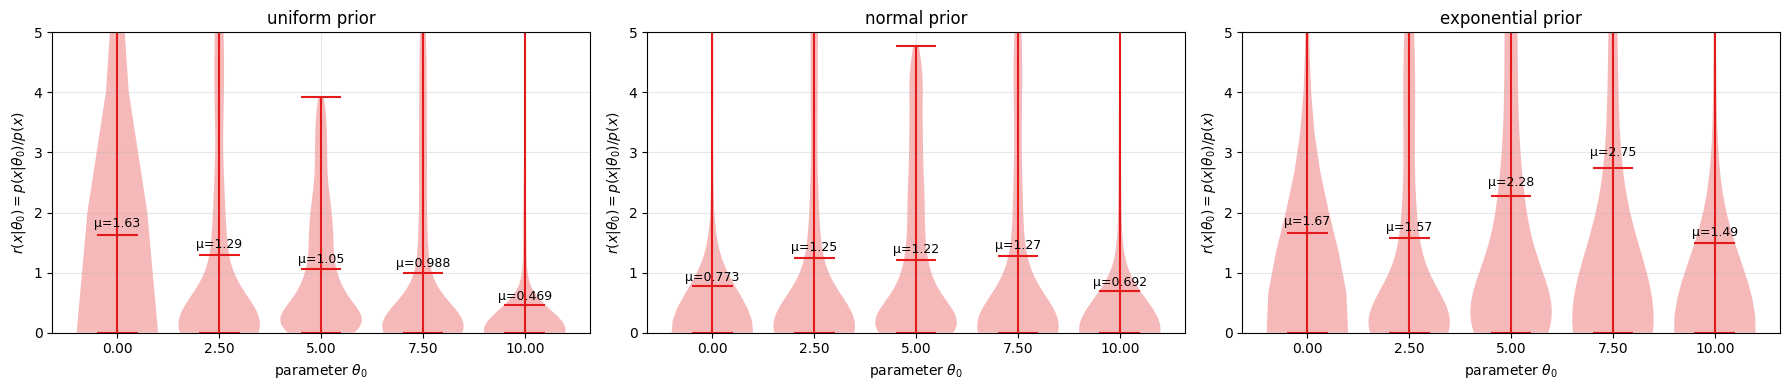

In [13]:
n_ratio_samples = 1_000
verification_parameters = generator.uniform(
    low=param_min,
    high=param_max,
    size=(n_ratio_samples, config["data"]["n_parameters"]),
)
verification_data = draw_data(verification_parameters, config, generator)
test_parameters = np.linspace(param_min, param_max, 5)
all_ratio_checks = calculate_all_ratios(
    verification_data,
    test_parameters,
    models=models,
    priors=priors,
    device=device,
)

filename_ratio_violins = get_filepath("verifications/ratio_violins.svg", config) if save else None
plot_ratio_violins(all_ratio_checks, test_parameters, filename=filename_ratio_violins)

#### Check II: reweighting

$R_{10}(x) = \frac{r(x|\theta_1)}{r(x|\theta_0)} = \frac{p(x|\theta_1)}{p(x|\theta_0)}$

if $p(x|\theta_1) = R_{10}(x)p(x|\theta_0)$: likelihood ratio trick holds

For the nD case below, the ratios use the full data vector while the plot visualizes the first observed component.

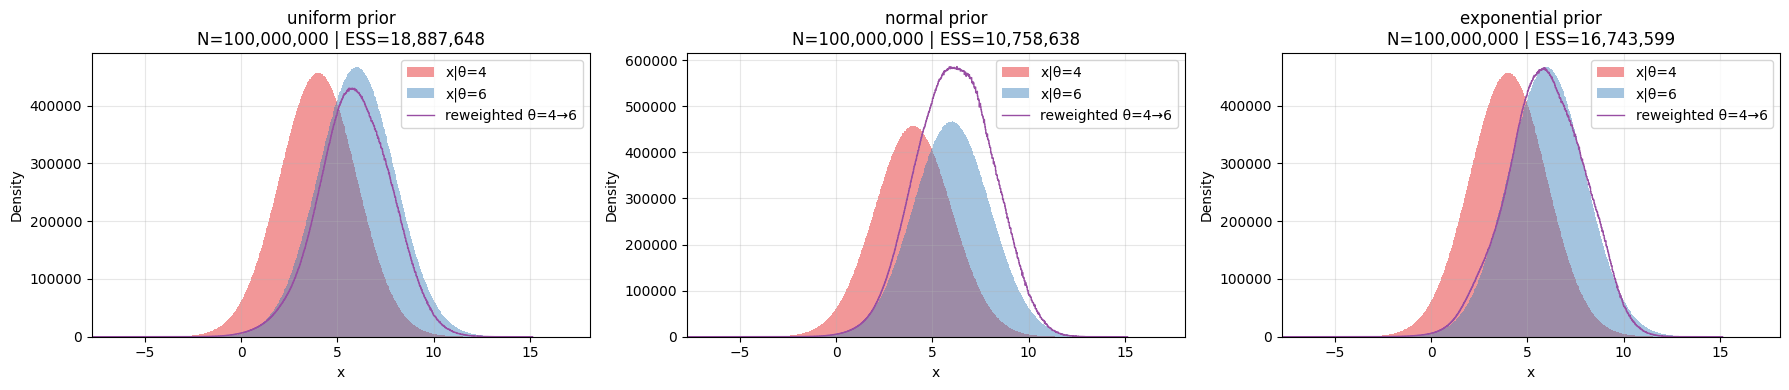

In [14]:
n_test_data = int(1e8)
n_bins = int(1e3)
test_parameter_sets = [(4, 6)]

for i, model_arr in enumerate(models):
    for test_parameter_set in test_parameter_sets:
        data_x, reweighted_distributions, reweighting_distributions, all_outs = reweight_distributions(
            test_parameter_set,
            model_arr,
            priors=priors,
            config=config,
            generator=generator,
            device=device,
            n_test_data=n_test_data,
            n_bins=n_bins,
            projection_dim=0,
        )
        filename_reweighted_distributions = get_filepath(
            f"verifications/reweighting_{i}/reweighted_distributions_{test_parameter_set[0]}_{test_parameter_set[1]}.svg",
            config,
        ) if save else None
        plot_reweighted_distributions(
            priors,
            data_x,
            reweighted_distributions,
            test_parameter_set,
            n_bins,
            reweighting_distributions=reweighting_distributions,
            filename=filename_reweighted_distributions,
        )

#### Check III: exact pairwise log-ratio error

Use the analytic Gaussian pairwise likelihood ratio as the reference target:

$\log R_{10}(x) = \frac{\lVert x-\theta_0\rVert^2 - \lVert x-\theta_1\rVert^2}{2\sigma^2}$

The learned score is $\log \hat{R}_{10}(x) = \operatorname{logit}(\hat{r}(x|\theta_1)) - \operatorname{logit}(\hat{r}(x|\theta_0))$. We evaluate many full-vector $(\theta_0, \theta_1)$ pairs and summarize the per-pair RMSE against the exact value.

uniform {'median_rmse_log_r10': 1.210663214197409, 'worst_rmse_log_r10': 6.203176483566963, 'pooled_rmse_log_r10': 2.180898114076047, 'spearman_rmse_vs_distance': 0.9860703812316713}
normal {'median_rmse_log_r10': 0.7247007002533825, 'worst_rmse_log_r10': 4.531405271877617, 'pooled_rmse_log_r10': 1.4891551333784163, 'spearman_rmse_vs_distance': 0.972140762463343}
exponential {'median_rmse_log_r10': 1.0903987523357455, 'worst_rmse_log_r10': 5.849834810557573, 'pooled_rmse_log_r10': 2.045179393720487, 'spearman_rmse_vs_distance': 0.9864369501466274}


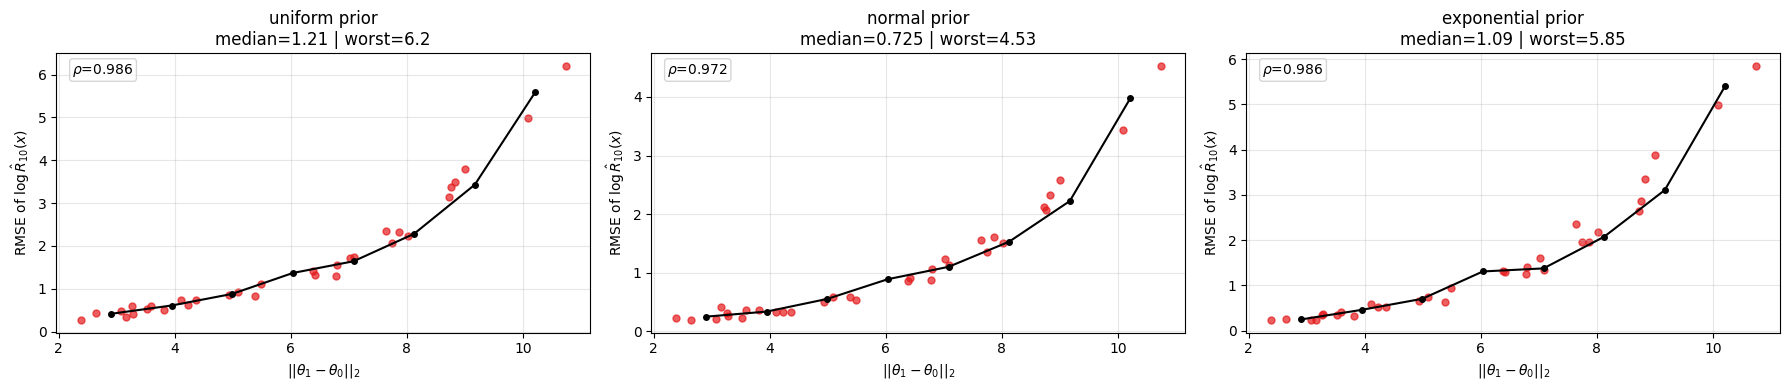

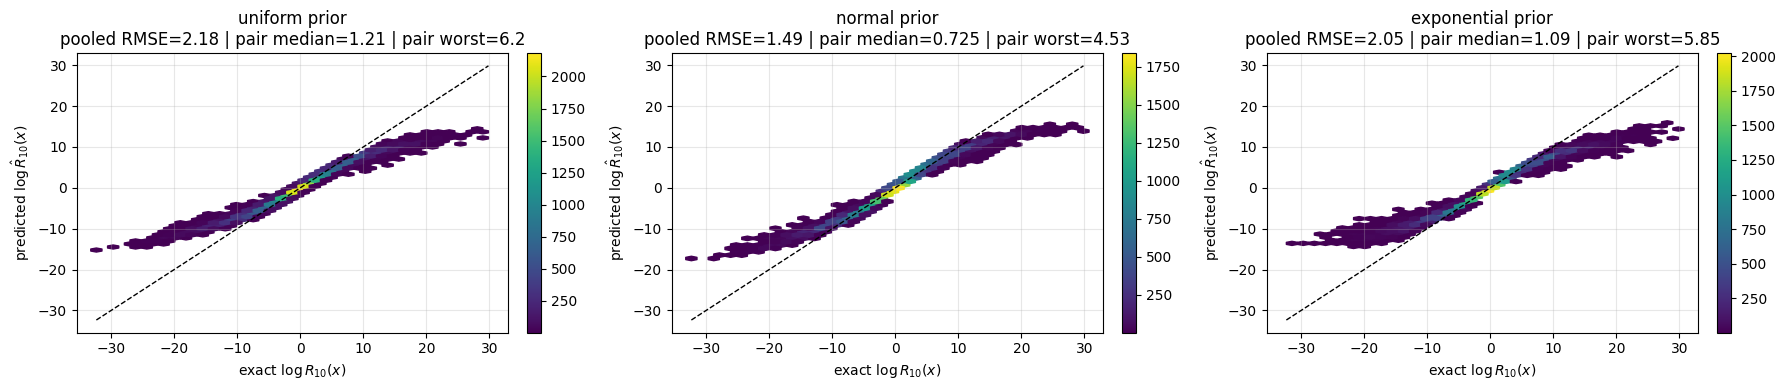

In [17]:
verification_pair_count = 32
verification_model_samples_per_endpoint = 512
verification_reweight_source_samples = 2_048
verification_reweight_target_samples = 2_048
verification_swd_projections = 32

quantitative_bundle = build_quantitative_verification_bundle(
    config=config,
    generator=generator,
    pair_count=verification_pair_count,
    model_samples_per_endpoint=verification_model_samples_per_endpoint,
    reweight_source_samples=verification_reweight_source_samples,
    reweight_target_samples=verification_reweight_target_samples,
    swd_projections=verification_swd_projections,
)

model_quality_results = evaluate_pairwise_log_ratio_quality(
    quantitative_bundle,
    models=models,
    priors=priors,
    device=device,
)

for prior_name, result in model_quality_results.items():
    print(prior_name, result["summary"])

filename_log_ratio_error_vs_distance = get_filepath("verifications/log_ratio_error_vs_distance.svg", config) if save else None
fig, _ = plot_log_ratio_error_vs_distance(
    model_quality_results,
    filename=filename_log_ratio_error_vs_distance,
)
#plt.close(fig)

filename_log_ratio_exact_vs_predicted = get_filepath("verifications/log_ratio_exact_vs_predicted.svg", config) if save else None
fig, _ = plot_log_ratio_exact_vs_predicted(
    model_quality_results,
    filename=filename_log_ratio_exact_vs_predicted,
)
#plt.close(fig)

model_quality_json = {
    prior_name: {
        "summary": {
            key: (None if np.isnan(float(value)) else float(value))
            for key, value in result["summary"].items()
        },
        "pair_metrics": {
            key: np.asarray(value, dtype=float).tolist()
            for key, value in result["pair_metrics"].items()
        },
    }
    for prior_name, result in model_quality_results.items()
}
filename_model_quality_json = get_filepath("verifications/model_quality_summary.json", config) if save else None
if filename_model_quality_json is not None:
    filename_model_quality_json.write_text(json.dumps(model_quality_json, indent=2, sort_keys=True))

#### Check IV: nD reweighting quality

Use weighted sliced Wasserstein-1 (SW1) as a bin-free nD reweighting metric. For each sampled pair $(\theta_0, \theta_1)$, compare the direct target sample $x_1 \sim p(x|\theta_1)$ against the source sample $x_0 \sim p(x|\theta_0)$ reweighted by the learned pairwise score. Report SW1, ESS, ESS fraction, and how the score changes with $\lVert \theta_1 - \theta_0 \rVert$.

uniform {'median_swd': 0.7479310923687555, 'worst_swd': 3.300977479895918, 'median_ess_fraction': 0.012628535318222198, 'worst_ess_fraction': 0.0016301969986891377, 'spearman_swd_vs_distance': 0.873533724340176}
normal {'median_swd': 0.8018956077137547, 'worst_swd': 3.1386710928600277, 'median_ess_fraction': 0.007518701339919682, 'worst_ess_fraction': 0.0008659872800684684, 'spearman_swd_vs_distance': 0.9424486803519062}
exponential {'median_swd': 0.731906296735618, 'worst_swd': 3.2549462692868536, 'median_ess_fraction': 0.010553295665422721, 'worst_ess_fraction': 0.0011544468618007936, 'spearman_swd_vs_distance': 0.935850439882698}


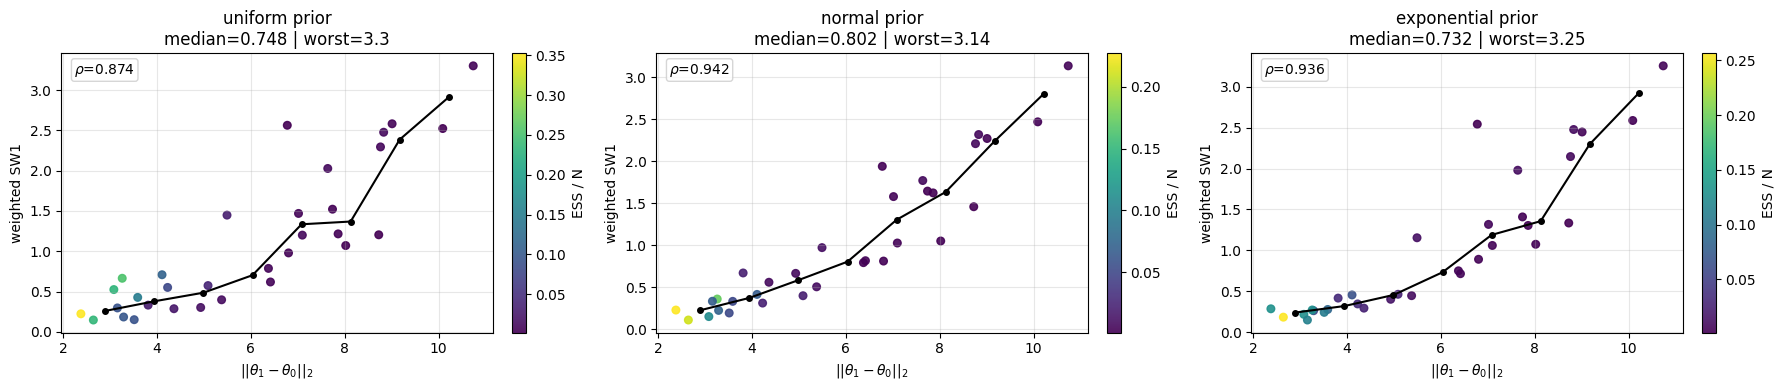

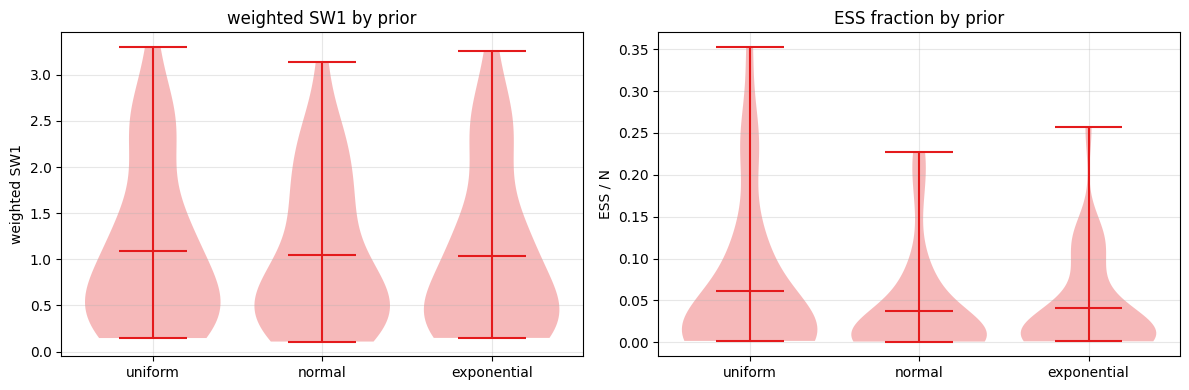

In [18]:
reweighting_quality_results = evaluate_nd_reweighting_quality(
    quantitative_bundle,
    models=models,
    priors=priors,
    device=device,
)

for prior_name, result in reweighting_quality_results.items():
    print(prior_name, result["summary"])

filename_reweighting_swd_vs_distance = get_filepath("verifications/reweighting_swd_vs_distance.svg", config) if save else None
fig, _ = plot_reweighting_swd_vs_distance(
    reweighting_quality_results,
    filename=filename_reweighting_swd_vs_distance,
)
#plt.close(fig)

filename_reweighting_summary = get_filepath("verifications/reweighting_summary.svg", config) if save else None
fig, _ = plot_reweighting_summary(
    reweighting_quality_results,
    filename=filename_reweighting_summary,
)
#plt.close(fig)

reweighting_quality_json = {
    prior_name: {
        "summary": {
            key: (None if np.isnan(float(value)) else float(value))
            for key, value in result["summary"].items()
        },
        "pair_metrics": {
            key: np.asarray(value, dtype=float).tolist()
            for key, value in result["pair_metrics"].items()
        },
    }
    for prior_name, result in reweighting_quality_results.items()
}
filename_reweighting_quality_json = get_filepath("verifications/reweighting_quality_summary.json", config) if save else None
if filename_reweighting_quality_json is not None:
    filename_reweighting_quality_json.write_text(json.dumps(reweighting_quality_json, indent=2, sort_keys=True))